In [1]:
import qsample as qs
import time
import stim
import numpy as np
import matplotlib.pyplot as plt
import pymatching

/Users/jhfontes/miniforge3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


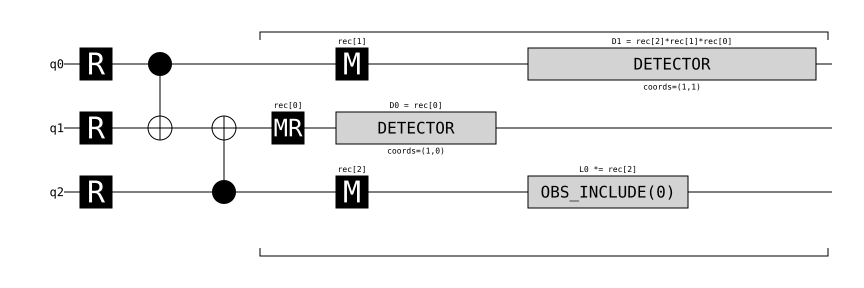

In [2]:
code = stim.Circuit.generated("repetition_code:memory", rounds=1, distance=2)
rep_code = qs.Circuit(noisy=True).from_stim_circuit(code)

code.diagram('timeline-svg')

p=('1.00e-03',): 100%|██████████| 2000/2000 [00:00<00:00, 13212.49it/s]


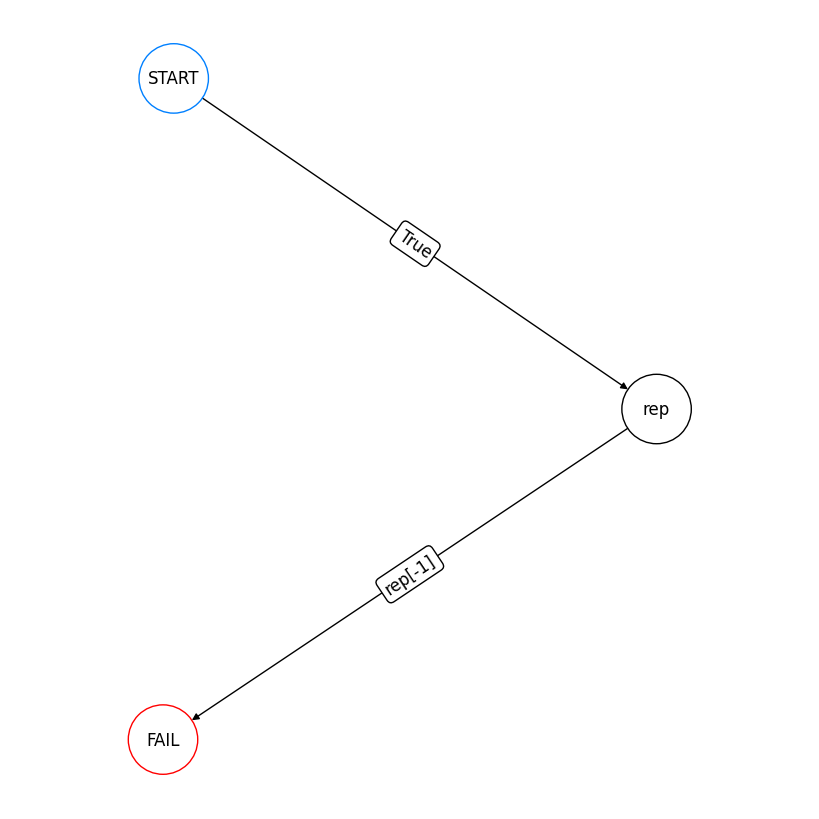

In [3]:
distance = 5
code = stim.Circuit.generated("repetition_code:memory", rounds=1, distance=distance, before_round_data_depolarization=0.01,
              before_measure_flip_probability=0.01)
rep_code = qs.Circuit(noisy=True).from_stim_circuit(code)

DEM = code.detector_error_model(decompose_errors=True)
decoder = pymatching.Matching.from_detector_error_model(DEM)




functions = {}
rep = qs.Protocol(check_functions=functions)


rep.add_nodes_from(['rep'], circuits=[rep_code])
rep.add_edge('START', 'rep', check='True')
rep.add_edge('rep', 'FAIL', check='rep[-1]')

rep.draw(figsize=(8,8), path='protocol_surface')

err_model = qs.noise.E1
stim_sam = qs.SplittingSampler(2000, protocol=rep, simulator=qs.StimSimulator,  p_max={'q': [0.001]}, err_model=err_model, distance=distance)
#stim_sam = qs.SplittingSampler(protocol=steane0, simulator=qs.StimSimulator,  err_model=err_model, err_params=err_params)
#stim_sam.run(1e-4)

## Code distance = 5, $T_{init}$ = 2,4,...,20

In [4]:
t_init = np.arange(2, 21, 2)
samples = 8

times = []
actual_lengths = []
p_l = []


for i in t_init:
    _p_l = []
    _times = []
    _actual_lengths = []
    for j in range(samples):
        stim_sam = qs.SplittingSampler(2000, protocol=rep, simulator=qs.StimSimulator,  p_max={'q': [0.001]}, err_model=err_model, distance=distance)
        
        begin_time = time.time()
        stim_sam.calculate_error(0.000001, i)
        end_time = time.time()

        _p_l.append(stim_sam.logical_p)
        _times.append(end_time-begin_time)
        _actual_lengths.append(stim_sam.actual_lengths)
    p_l.append(_p_l)
    times.append(_times)
    actual_lengths.append(_actual_lengths)

100%|██████████| 16/16 [00:00<00:00, 33.82it/s]


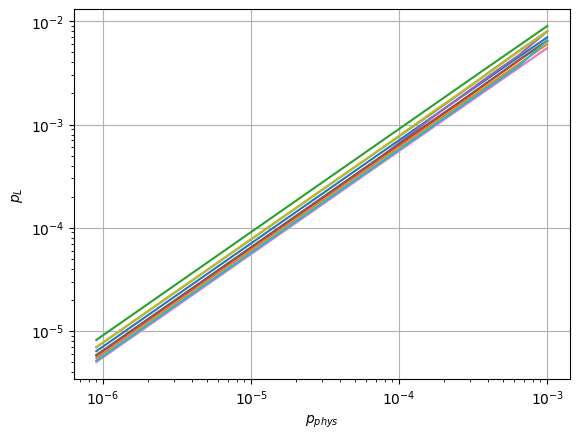

In [5]:
plt.plot(stim_sam.physical_p, (np.array(p_l)[:,0].T)[0])
plt.yscale('log')
plt.xscale('log')
plt.xlabel('$p_{phys}$')
plt.ylabel('$p_L$')
plt.grid()

/var/folders/dd/4yhpjrt92t3fr6_cq5glj9b80000gn/T/ipykernel_16542/2663777925.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0,1].legend()


Text(0.5, 0, '$T_{init}$')

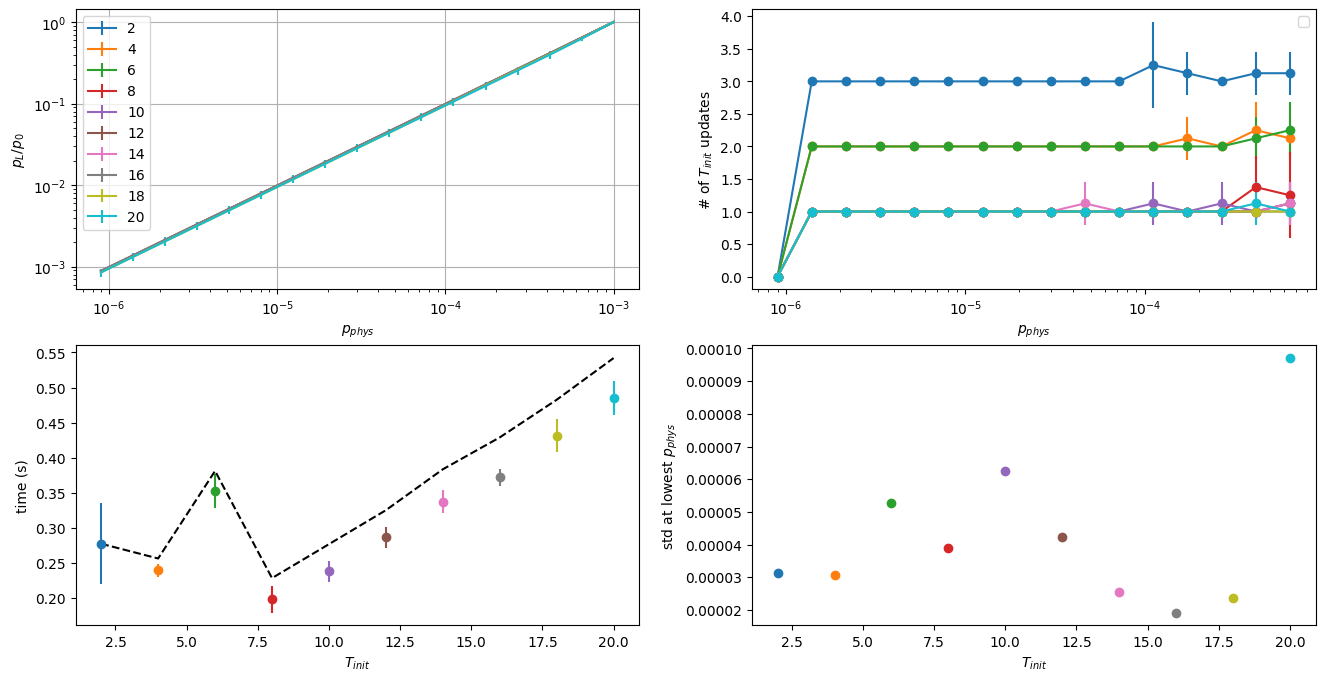

In [6]:
p_l_array = np.array(p_l).reshape(len(t_init)*samples, -1)
p_l_normalized = (p_l_array/np.outer(p_l_array[:,0], np.ones(17))).reshape(len(t_init), samples, -1)

fig, ax = plt.subplots(2, 2, figsize=(16,8))
p_avg = np.average(p_l_normalized, axis=1)
p_std = np.std(p_l_normalized, axis=1)

for i in range(len(t_init)):
    ax[0,0].errorbar(stim_sam.physical_p, p_avg[i], p_std[i], label=t_init[i])
ax[0,0].set_yscale('log')
ax[0,0].set_xlabel('$p_{phys}$')
ax[0,0].set_ylabel('$p_L/p_0$')
ax[0,0].set_xscale('log')
ax[0,0].legend()
ax[0,0].grid()

lengths = np.log2(np.array(actual_lengths)/np.repeat(t_init, samples*16).reshape(-1, samples, 16)+1)-1
lengths_avg = np.average(lengths, axis=1)
lengths_std = np.std(lengths, axis=1)

for i in range(len(t_init)):
    ax[0,1].errorbar(stim_sam.physical_p[1:], lengths_avg[i], lengths_std[i], fmt='o-')
ax[0,1].set_xscale('log')
ax[0,1].set_xlabel('$p_{phys}$')
ax[0,1].set_ylabel('# of $T_{init}$ updates')
ax[0,1].legend()

expected = np.average(np.sum(np.array(actual_lengths), axis=2), axis=1)

t_avg = np.average(np.array(times), axis=1)
t_std = np.std(np.array(times), axis=1)
for i in range(len(t_init)):
    ax[1,0].errorbar(t_init[i], t_avg[i], t_std[i], fmt='o')
ax[1,0].plot(t_init, expected*t_avg[0]/expected[0], 'k--')
ax[1,0].set_ylabel('time (s)')
ax[1,0].set_xlabel('$T_{init}$')

for i in range(len(t_init)):
    ax[1,1].scatter(t_init[i], p_std[i,-1])
ax[1,1].set_ylabel('std at lowest $p_{phys}$')
ax[1,1].set_xlabel('$T_{init}$')

## Code distance = 5, $T_{init}$ = 10,20,...,100

In [7]:
t_init = np.arange(10, 100, 10)
samples = 8

times = []
actual_lengths = []
p_l = []


for i in t_init:
    _p_l = []
    _times = []
    _actual_lengths = []
    for j in range(samples):
        stim_sam = qs.SplittingSampler(2000, protocol=rep, simulator=qs.StimSimulator,  p_max={'q': [0.001]}, err_model=err_model, distance=distance)
        
        begin_time = time.time()
        stim_sam.calculate_error(0.000001, i)
        end_time = time.time()

        _p_l.append(stim_sam.logical_p)
        _times.append(end_time-begin_time)
        _actual_lengths.append(stim_sam.actual_lengths)
    p_l.append(_p_l)
    times.append(_times)
    actual_lengths.append(_actual_lengths)

100%|██████████| 16/16 [00:00<00:00, 20.24it/s]


/var/folders/dd/4yhpjrt92t3fr6_cq5glj9b80000gn/T/ipykernel_16542/2663777925.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0,1].legend()


Text(0.5, 0, '$T_{init}$')

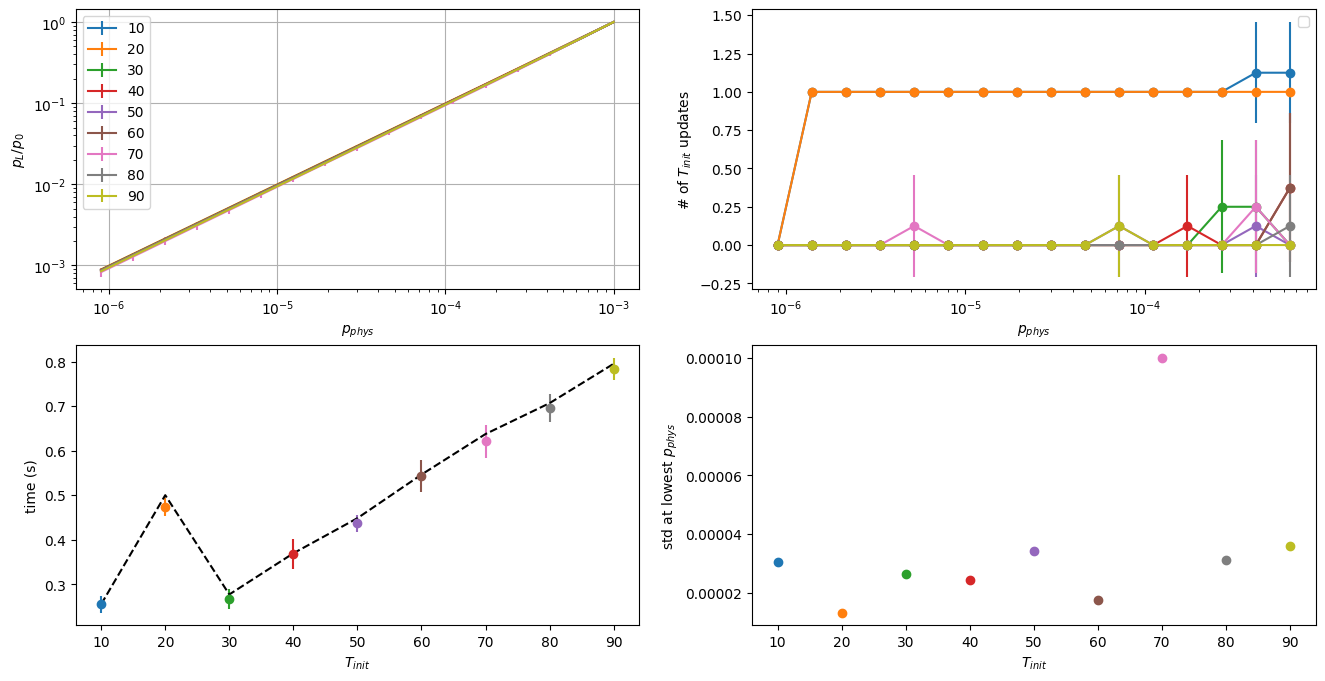

In [8]:
p_l_array = np.array(p_l).reshape(len(t_init)*samples, -1)
p_l_normalized = (p_l_array/np.outer(p_l_array[:,0], np.ones(17))).reshape(len(t_init), samples, -1)

fig, ax = plt.subplots(2, 2, figsize=(16,8))
p_avg = np.average(p_l_normalized, axis=1)
p_std = np.std(p_l_normalized, axis=1)

for i in range(len(t_init)):
    ax[0,0].errorbar(stim_sam.physical_p, p_avg[i], p_std[i], label=t_init[i])
ax[0,0].set_yscale('log')
ax[0,0].set_xlabel('$p_{phys}$')
ax[0,0].set_ylabel('$p_L/p_0$')
ax[0,0].set_xscale('log')
ax[0,0].legend()
ax[0,0].grid()

lengths = np.log2(np.array(actual_lengths)/np.repeat(t_init, samples*16).reshape(-1, samples, 16)+1)-1
lengths_avg = np.average(lengths, axis=1)
lengths_std = np.std(lengths, axis=1)

for i in range(len(t_init)):
    ax[0,1].errorbar(stim_sam.physical_p[1:], lengths_avg[i], lengths_std[i], fmt='o-')
ax[0,1].set_xscale('log')
ax[0,1].set_xlabel('$p_{phys}$')
ax[0,1].set_ylabel('# of $T_{init}$ updates')
ax[0,1].legend()

expected = np.average(np.sum(np.array(actual_lengths), axis=2), axis=1)

t_avg = np.average(np.array(times), axis=1)
t_std = np.std(np.array(times), axis=1)
for i in range(len(t_init)):
    ax[1,0].errorbar(t_init[i], t_avg[i], t_std[i], fmt='o')
ax[1,0].plot(t_init, expected*t_avg[0]/expected[0], 'k--')
ax[1,0].set_ylabel('time (s)')
ax[1,0].set_xlabel('$T_{init}$')

for i in range(len(t_init)):
    ax[1,1].scatter(t_init[i], p_std[i,-1])
ax[1,1].set_ylabel('std at lowest $p_{phys}$')
ax[1,1].set_xlabel('$T_{init}$')

Observation: Increasing T_init does not improve the accuracy, so we can stick with T_init = 8.

## Code distance = 11, $T_{init}$=2,4,...,20

In [10]:
distance = 11
code = stim.Circuit.generated("repetition_code:memory", rounds=1, distance=distance, before_round_data_depolarization=0.01,
              before_measure_flip_probability=0.01)
rep_code = qs.Circuit(noisy=True).from_stim_circuit(code)

DEM = code.detector_error_model(decompose_errors=True)
decoder = pymatching.Matching.from_detector_error_model(DEM)

functions = {}
rep = qs.Protocol(check_functions=functions)


rep.add_nodes_from(['rep'], circuits=[rep_code])
rep.add_edge('START', 'rep', check='True')
rep.add_edge('rep', 'FAIL', check='rep[-1]')

err_model = qs.noise.E1
stim_sam = qs.SplittingSampler(2000, protocol=rep, simulator=qs.StimSimulator,  p_max={'q': [0.001]}, err_model=err_model, distance=distance)

p=('1.00e-03',): 100%|██████████| 2000/2000 [00:00<00:00, 8279.96it/s]


In [11]:
t_init = np.arange(2, 21, 2)
samples = 8

times = []
actual_lengths = []
p_l = []


for i in t_init:
    _p_l = []
    _times = []
    _actual_lengths = []
    for j in range(samples):
        stim_sam = qs.SplittingSampler(2000, protocol=rep, simulator=qs.StimSimulator,  p_max={'q': [0.001]}, err_model=err_model, distance=distance)
        
        begin_time = time.time()
        stim_sam.calculate_error(0.000001, i)
        end_time = time.time()

        _p_l.append(stim_sam.logical_p)
        _times.append(end_time-begin_time)
        _actual_lengths.append(stim_sam.actual_lengths)
    p_l.append(_p_l)
    times.append(_times)
    actual_lengths.append(_actual_lengths)

100%|██████████| 24/24 [00:01<00:00, 12.79it/s]


/var/folders/dd/4yhpjrt92t3fr6_cq5glj9b80000gn/T/ipykernel_16542/584170534.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0,1].legend()


Text(0.5, 0, '$T_{init}$')

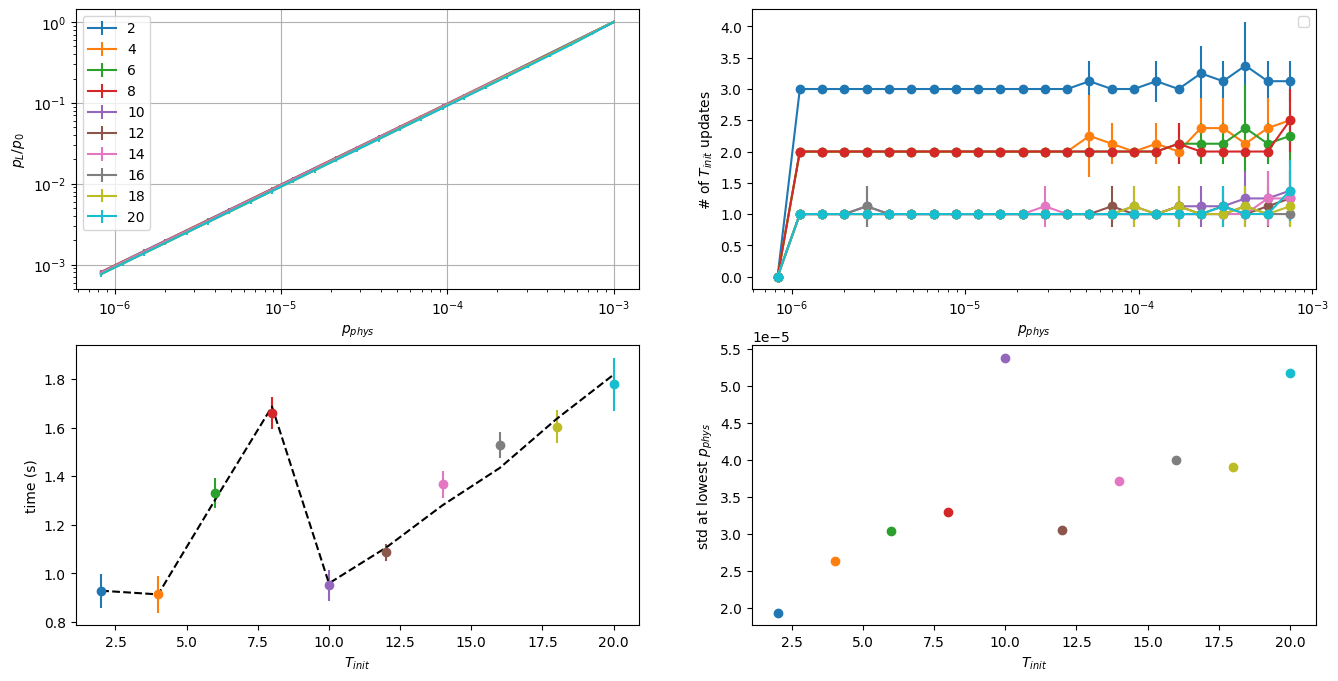

In [12]:
p_l_array = np.array(p_l).reshape(len(t_init)*samples, -1)
p_l_normalized = (p_l_array/np.outer(p_l_array[:,0], np.ones(25))).reshape(len(t_init), samples, -1)

fig, ax = plt.subplots(2, 2, figsize=(16,8))
p_avg = np.average(p_l_normalized, axis=1)
p_std = np.std(p_l_normalized, axis=1)

for i in range(len(t_init)):
    ax[0,0].errorbar(stim_sam.physical_p, p_avg[i], p_std[i], label=t_init[i])
ax[0,0].set_yscale('log')
ax[0,0].set_xlabel('$p_{phys}$')
ax[0,0].set_ylabel('$p_L/p_0$')
ax[0,0].set_xscale('log')
ax[0,0].legend()
ax[0,0].grid()

lengths = np.log2(np.array(actual_lengths)/np.repeat(t_init, samples*24).reshape(-1, samples, 24)+1)-1
lengths_avg = np.average(lengths, axis=1)
lengths_std = np.std(lengths, axis=1)

for i in range(len(t_init)):
    ax[0,1].errorbar(stim_sam.physical_p[1:], lengths_avg[i], lengths_std[i], fmt='o-')
ax[0,1].set_xscale('log')
ax[0,1].set_xlabel('$p_{phys}$')
ax[0,1].set_ylabel('# of $T_{init}$ updates')
ax[0,1].legend()

expected = np.average(np.sum(np.array(actual_lengths), axis=2), axis=1)

t_avg = np.average(np.array(times), axis=1)
t_std = np.std(np.array(times), axis=1)
for i in range(len(t_init)):
    ax[1,0].errorbar(t_init[i], t_avg[i], t_std[i], fmt='o')
ax[1,0].plot(t_init, expected*t_avg[0]/expected[0], 'k--')
ax[1,0].set_ylabel('time (s)')
ax[1,0].set_xlabel('$T_{init}$')

for i in range(len(t_init)):
    ax[1,1].scatter(t_init[i], p_std[i,-1])
ax[1,1].set_ylabel('std at lowest $p_{phys}$')
ax[1,1].set_xlabel('$T_{init}$')

p=('1.00e-03',): 100%|██████████| 2000/2000 [00:00<00:00, 6472.06it/s]


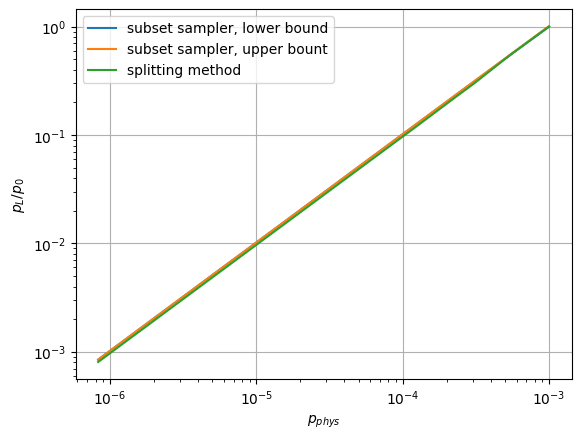

In [19]:
err_params = {'q': stim_sam.physical_p}

subset_sam = qs.SubsetSampler(protocol=rep, simulator=qs.StimSimulator,  p_max={'q': 0.001}, err_model=err_model, err_params=err_params, L=3)
subset_sam.run(2000)

v = subset_sam.stats()[0]
w = subset_sam.stats()[2]

plt.plot(stim_sam.physical_p, v/v[0], label = "subset sampler, lower bound")
plt.plot(stim_sam.physical_p, w/v[0], label = "subset sampler, upper bount")
plt.plot(stim_sam.physical_p, p_l_array[0]/p_l_array[0,0], label = "splitting method")
plt.legend()
plt.xscale('log')
plt.xlabel('$p_{phys}$')
plt.ylabel('$p_L/p_0$')
plt.yscale('log')
plt.grid()

In [13]:
# accuracy vs. time
# what causes the errors for short Markov chains
# change reference p value for subset sampler
# check different code distances


# implement some error correction
# figure out why it does this (fixing seed of random number) NOT OK
# find regime where it's advantageous

# think about lifetime measurements
# try to parallelize stuff 